# Task 5: Train the Final Model Instance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, matthews_corrcoef
import optuna
import shap

# Set random seed
np.random.seed(42)
optuna.logging.set_verbosity(optuna.logging.WARNING)

## Step 5.1: Select Best Hyperparameters Using 5-Fold CV

In [3]:
# Load data
df = pd.read_csv('../data/students_dataset.csv')

# Separate features and target
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
target_col = 'num'
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Dataset shape: {X.shape}")
print(f"Class distribution:")
print(y.value_counts())

Dataset shape: (242, 13)
Class distribution:
num
0    131
1    111
Name: count, dtype: int64


### Define Hyperparameter Space for LR

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

def lr_objective(trial):
    """
    Optuna objective function for Logistic Regression hyperparameter tuning.

    C: Regularization strength (log-uniform between 1e-4 and 1e2)
    penalty: l1 or l2 regularization
    solver: compatible solver for each penalty type
    """
    # Sample hyperparameters
    C = trial.suggest_float('C', 1e-4, 1e2, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear'  # supports both l1 and l2

    # Create pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler",  StandardScaler())
            ]), numerical_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]), categorical_features),
        ]
    )
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000, random_state=42)),
    ])

    # 5-fold CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

    return scores.mean()

print("Starting hyperparameter optimization...")
print("Using 5-fold CV with ROC-AUC as optimization metric")

In [ ]:
# Run Optuna optimization
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(lr_objective, n_trials=50, show_progress_bar=True)

print("Optimization completed!")
print(f"\nBest ROC-AUC: {study.best_value:.4f}")
print(f"Best hyperparameters: {study.best_params}")

In [ ]:
# Extract best hyperparameters
best_C = study.best_params['C']
best_penalty = study.best_params['penalty']

print(f"\nOptimal C: {best_C:.4f}")
print(f"Optimal penalty: {best_penalty}")
print(f"Solver: liblinear")

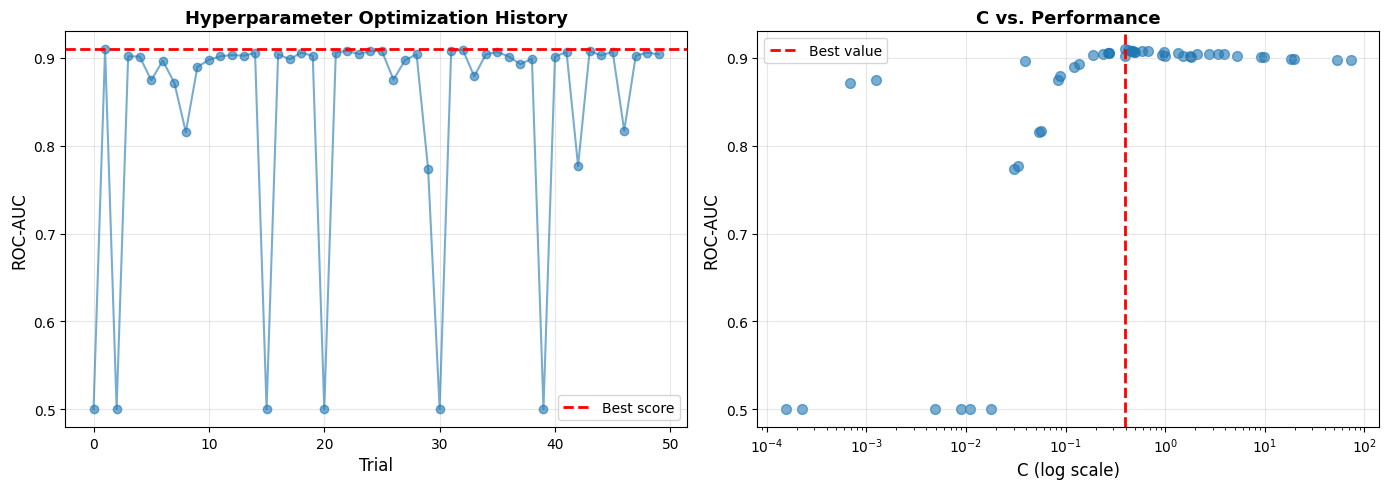

In [ ]:
# Visualize optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Optimization history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], marker='o', linestyle='-', alpha=0.6)
axes[0].axhline(y=study.best_value, color='red', linestyle='--', linewidth=2, label='Best score')
axes[0].set_xlabel('Trial', fontsize=12)
axes[0].set_ylabel('ROC-AUC', fontsize=12)
axes[0].set_title('Hyperparameter Optimization History', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: C vs performance
axes[1].scatter(trials_df['params_C'], trials_df['value'], alpha=0.6, s=50)
axes[1].axvline(x=best_C, color='red', linestyle='--', linewidth=2, label='Best value')
axes[1].set_xscale('log')
axes[1].set_xlabel('C (log scale)', fontsize=12)
axes[1].set_ylabel('ROC-AUC', fontsize=12)
axes[1].set_title('C vs. Performance', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig_lr_hyperparameter_optimization.png', dpi=300)
plt.show()

## Step 5.2: Train Final Model on ALL Data

In [ ]:
# Create final pipeline with optimal hyperparameters
preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numerical_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]), categorical_features),
        ]
    )
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(C=best_C, penalty=best_penalty, solver="liblinear", max_iter=1000, random_state=42)),
])

print("Training final model on ALL data...")
print(f"Pipeline steps:")
print(f"  1. Imputer: median strategy")
print(f"  2. Scaler: StandardScaler")
print(f"  3. Classifier: LogisticRegression(C={best_C:.4f}, penalty='{best_penalty}', solver='liblinear')")

In [ ]:
# Train on all data
final_pipeline.fit(X, y)

print("\nModel training completed!")
print(f"Trained on {len(X)} samples")
print(f"Using {X.shape[1]} features")

In [ ]:
# Verify pipeline works correctly
y_pred = final_pipeline.predict(X)
y_proba = final_pipeline.predict_proba(X)[:, 1]

# Training performance (just for verification - NOT generalization estimate)
train_auc = roc_auc_score(y, y_proba)
train_mcc = matthews_corrcoef(y, y_pred)

print("\nTraining set performance (for verification only):")
print(f"ROC-AUC: {train_auc:.4f}")
print(f"MCC: {train_mcc:.4f}")
print("\nNote: These are NOT generalization estimates!")
print("      Use Task 3 rnCV results for true performance.")


Training set performance (for verification only):
  ROC-AUC: 0.9262
  MCC: 0.7171

Note: These are NOT generalization estimates!
      Use Task 3 rnCV results for true performance.


### Save Final Model

In [ ]:
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the complete pipeline
model_path = '../models/final_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(final_pipeline, f)

print(f"Final model saved to: {model_path}")

# Verify file size
file_size = os.path.getsize(model_path) / 1024  # KB
print(f"File size: {file_size:.2f} KB")

In [ ]:
# Test loading the saved model
print("\nVerifying saved model...")

with open(model_path, 'rb') as f:
    loaded_pipeline = pickle.load(f)

# Test prediction
test_pred = loaded_pipeline.predict(X.iloc[:5])
test_proba = loaded_pipeline.predict_proba(X.iloc[:5])

print("Model loaded successfully!")
print(f"Predictions work correctly")
print(f"\nExample predictions (first 5 samples):")
for i in range(5):
    print(f"Sample {i+1}: Class {test_pred[i]} (proba: {test_proba[i][1]:.3f})")

## Step 5.3: Model Interpretation using SHAP Values

### Prepare Data for SHAP

SHAP needs the preprocessed features (after imputation and scaling).

In [ ]:
preprocessor = final_pipeline.named_steps['preprocessor']
X_preprocessed = preprocessor.transform(X)

feature_names_out = preprocessor.get_feature_names_out()
print(feature_names_out)
# Clean up the feature names (ColumnTransformer adds prefixes like 'num__' and 'cat__')
clean_feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names_out]

print(f"Preprocessed data shape: {X_preprocessed.shape}")
print(f"Feature names: {list(X.columns)}")

['num__age' 'num__trestbps' 'num__chol' 'num__thalach' 'num__oldpeak'
 'cat__sex_0.0' 'cat__sex_1.0' 'cat__cp_1.0' 'cat__cp_2.0' 'cat__cp_3.0'
 'cat__cp_4.0' 'cat__fbs_0.0' 'cat__fbs_1.0' 'cat__restecg_0.0'
 'cat__restecg_1.0' 'cat__restecg_2.0' 'cat__exang_0.0' 'cat__exang_1.0'
 'cat__slope_1.0' 'cat__slope_2.0' 'cat__slope_3.0' 'cat__ca_0.0'
 'cat__ca_1.0' 'cat__ca_2.0' 'cat__ca_3.0' 'cat__thal_3.0' 'cat__thal_6.0'
 'cat__thal_7.0']
Preprocessed data shape: (242, 28)
Feature names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


### Create SHAP Explainer

In [ ]:
print("Creating SHAP explainer...")

# Extract the trained classifier
lr_model = final_pipeline.named_steps['clf']

# Create LinearExplainer — exact and efficient for logistic regression
explainer = shap.LinearExplainer(
    lr_model,
    X_preprocessed,
    feature_perturbation='interventional'
)

print("Explainer created!")

In [ ]:
# Compute SHAP values for all samples
print("\nComputing SHAP values for all samples...")
print("This will take several minutes...")

shap_values = explainer(X_preprocessed)

print("SHAP values computed!")
print(f"Shape: {shap_values.values.shape}")

### SHAP Visualizations

#### 1. Summary Plot (Bar) - Feature Importance

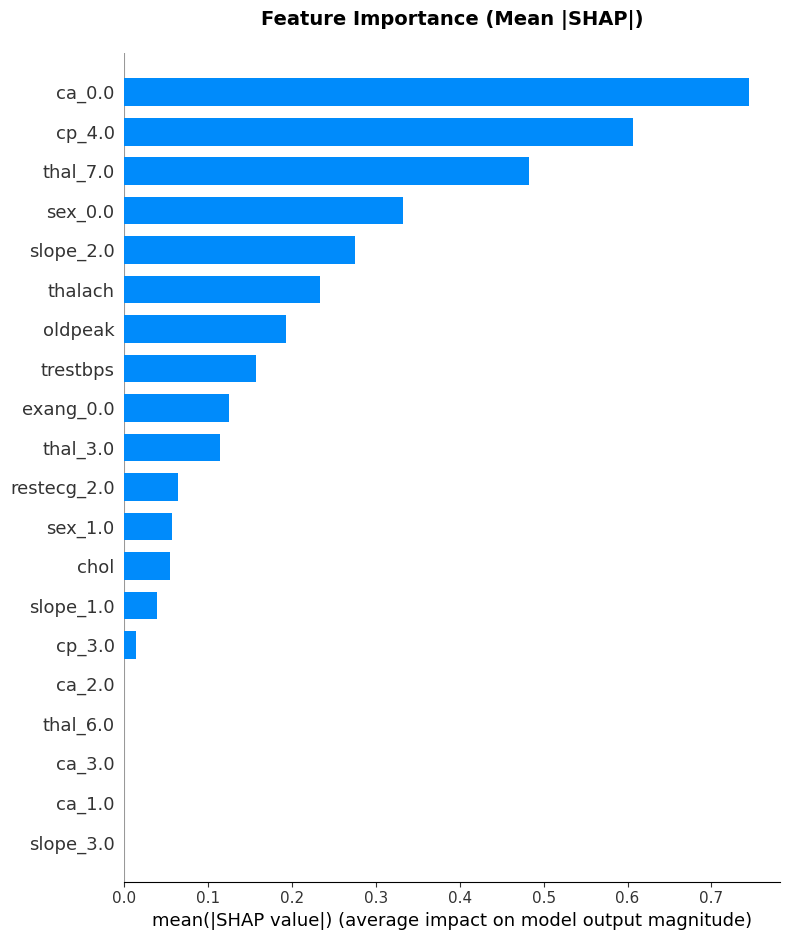


Interpretation:
  Features are ranked by average absolute SHAP value.
  Higher values = stronger influence on predictions.


In [ ]:
# SHAP values for class 1 (disease)
shap_values_class1 = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_class1, 
    X_preprocessed, 
    feature_names=clean_feature_names,
    plot_type='bar',
    show=False
)
plt.title('Feature Importance (Mean |SHAP|)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/fig_lr_shap_summary.png', dpi=300)
plt.show()

print("\nInterpretation:")
print("Features are ranked by average absolute SHAP value.")
print("Higher values = stronger influence on predictions.")

#### 2. Summary Plot (Beeswarm) - Feature Effects

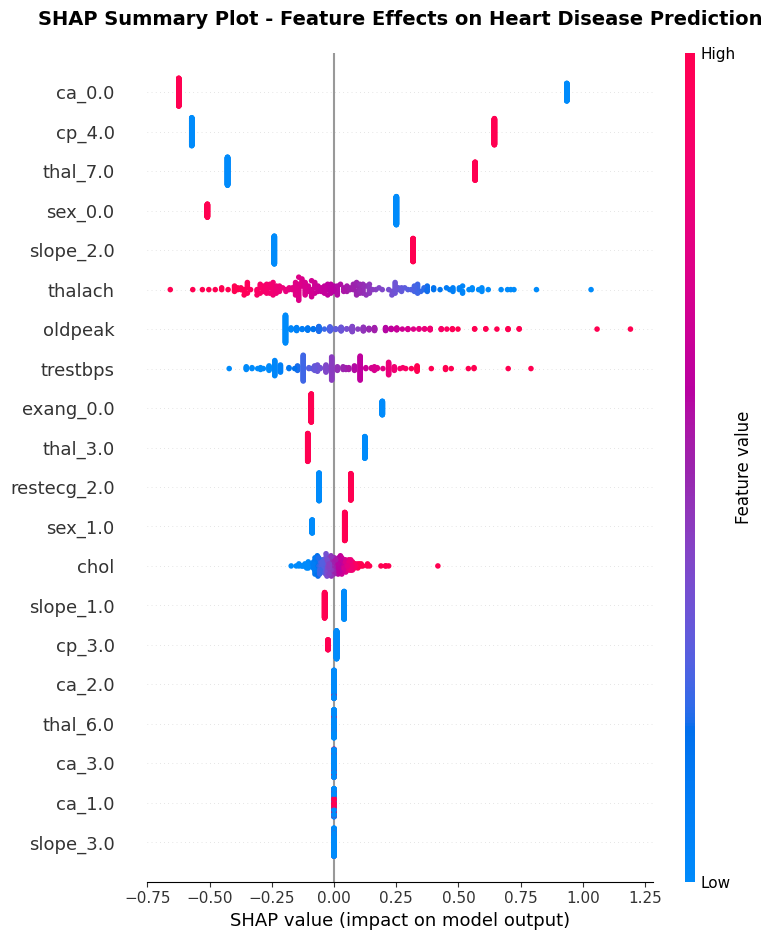


Interpretation:
  • Each dot is a patient
  • X-axis: SHAP value (impact on prediction)
  • Color: Feature value (red=high, blue=low)
  • Right side: increases disease probability
  • Left side: decreases disease probability


In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_class1,
    X_preprocessed,
    feature_names=clean_feature_names,
    show=False
)
plt.title('SHAP Summary Plot - Feature Effects on Heart Disease Prediction', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/fig_lr_shap_summary_scatter.png', dpi=300)
plt.show()

print("\nInterpretation:")
print("Each dot is a patient")
print("X-axis: SHAP value (impact on prediction)")
print("Color: Feature value (red=high, blue=low)")
print("Right side: increases disease probability")
print("Left side: decreases disease probability")

#### 3. Feature Dependence Plots - Top 3 Features

In [25]:
# Get top 3 most important features
mean_abs_shap = np.abs(shap_values_class1.values).mean(axis=0)
top_3_idx = np.argsort(mean_abs_shap)[-3:][::-1]
top_3_features = [clean_feature_names[i] for i in top_3_idx]

print(f"Top 3 most important features:")
for i, feat in enumerate(top_3_features, 1):
    print(f"  {i}. {feat}")

Top 3 most important features:
  1. ca_0.0
  2. cp_4.0
  3. thal_7.0
